<h1>
  Análise de Preços
</h1>

## Bibliotecas

In [1]:
import pandas as pd
import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mtick

## Funções

In [2]:
from os import truncate
def carregar_df_csv(caminho:str):
    df = pd.read_csv(caminho)
    return df

def transformar_spark(sessao_spark,df:pd.DataFrame):
 return sessao_spark.createDataFrame(df)

def criar_view(df, nome_view):
 return df.createOrReplaceTempView(nome_view)

def executar_sql(sessao_spark, query):
  return sessao_spark.sql(query)

def ver_df(df):
  return df.show(truncate=False)

## ETL

In [3]:
sessao_spark = SparkSession.builder.appName("Análise de NPS").getOrCreate()

In [4]:
caminho_clientes = "../data/olist_customers_dataset.csv"
caminho_itens = "../data/olist_order_items_dataset.csv"
caminho_pedidos = "../data/olist_orders_dataset.csv"
caminho_avaliacoes = "../data/olist_order_reviews_dataset.csv"
caminho_produtos = "../data/olist_products_dataset.csv"
caminho_vendedores = "../data/olist_sellers_dataset.csv"

## Clientes

In [5]:
df_clientes = carregar_df_csv(caminho_clientes)

df_clientes = transformar_spark(sessao_spark,df_clientes)

criar_view(df_clientes,"dim_clientes")

## Itens

In [6]:
df_itens = carregar_df_csv(caminho_itens)

df_itens = transformar_spark(sessao_spark,df_itens)

criar_view(df_itens,"fat_itens")

## Pedidos

In [7]:
df_pedidos = carregar_df_csv(caminho_pedidos)

df_pedidos = transformar_spark(sessao_spark,df_pedidos)

criar_view(df_pedidos,"fat_pedidos")

## Avaliações

In [8]:
df_avaliacoes = carregar_df_csv(caminho_avaliacoes)

df_avaliacoes = transformar_spark(sessao_spark,df_avaliacoes)

criar_view(df_avaliacoes,"dim_avaliacoes")

## Produtos

In [9]:
df_produtos = carregar_df_csv(caminho_produtos)

df_produtos = transformar_spark(sessao_spark,df_produtos)

criar_view(df_produtos,"dim_produtos")

## Vendedores

In [10]:
df_vendedores = carregar_df_csv(caminho_vendedores)

df_vendedores = transformar_spark(sessao_spark,df_vendedores)

criar_view(df_vendedores,"dim_vendedores")

## Unindo a nota ao pedido

In [11]:
consulta_avaliacoes = \
"""
SELECT
p.order_id AS id_pedido,
c.customer_unique_id AS id_cliente,
prod.product_category_name AS categoria_produto,
p.order_status AS status,
av.review_score AS nota,
c.customer_city AS cidade_cliente,
c.customer_state AS estado_cliente,
ROUND(i.price,2) AS valor_produto,
ROUND(i.freight_value,2) AS valor_frete,
ROUND(i.price + i.freight_value,2) AS valor_total,
av.review_creation_date AS data_avaliacao,
p.order_delivered_customer_date AS data_entrega_cliente
FROM fat_pedidos p
INNER JOIN dim_avaliacoes av
ON av.order_id = p.order_id
INNER JOIN dim_clientes c
ON  c.customer_id = p.customer_id
INNER JOIN fat_itens i
ON i.order_id = p.order_id
INNER JOIN dim_produtos prod
ON prod.product_id = i.product_id
WHERE p.order_status = 'delivered'


"""


df_avaliacoes = executar_sql(sessao_spark, consulta_avaliacoes)

In [12]:
ver_df(df_avaliacoes)

+--------------------------------+--------------------------------+----------------------+---------+----+---------------+--------------+-------------+-----------+-----------+-------------------+--------------------+
|id_pedido                       |id_cliente                      |categoria_produto     |status   |nota|cidade_cliente |estado_cliente|valor_produto|valor_frete|valor_total|data_avaliacao     |data_entrega_cliente|
+--------------------------------+--------------------------------+----------------------+---------+----+---------------+--------------+-------------+-----------+-----------+-------------------+--------------------+
|0132451f29a10b66a5cf1bacc85f9afe|aaff146bd210808c7d004a05966472a7|cama_mesa_banho       |delivered|5   |sao goncalo    |RJ            |89.9         |17.88      |107.78     |2017-11-18 00:00:00|2017-11-17 18:58:42 |
|036091098bdc85e780fc3594006276b7|91049771b745aa43500e4c82ed6a2241|cama_mesa_banho       |delivered|5   |sao paulo      |SP            |

In [13]:
criar_view(df_avaliacoes,"fat_pedidos_avaliados")

In [14]:
consulta_aval_somadas = \
"""
SELECT SUM(valor_total) AS total_gasto, estado_cliente
FROM fat_pedidos_avaliados
GROUP BY valor_total, estado_cliente
"""

df_total_gasto = executar_sql(sessao_spark, consulta_aval_somadas)

In [15]:
ver_df(df_total_gasto)

+------------------+--------------+
|total_gasto       |estado_cliente|
+------------------+--------------+
|502.16999999999996|BA            |
|308.2             |MG            |
|199.84            |BA            |
|240.18            |DF            |
|243.71999999999997|SP            |
|373.22            |MG            |
|378.84            |MG            |
|461.3             |MG            |
|110.4             |RS            |
|1098.54           |SP            |
|298.95000000000005|MG            |
|112.22            |RJ            |
|718.9600000000004 |SP            |
|222.14            |MG            |
|169.37            |SP            |
|209.79            |RJ            |
|191.38            |PE            |
|380.88            |RJ            |
|680.22            |SP            |
|118.58            |GO            |
+------------------+--------------+
only showing top 20 rows



## Análise exploratória

In [16]:
# Quantidade de registros
df_avaliacoes.count()

110013

In [17]:
#Quantidade de registros nulos por coluna:

df_avaliacoes.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_avaliacoes.columns
]).show()

+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+
|id_pedido|id_cliente|categoria_produto|status|nota|cidade_cliente|estado_cliente|valor_produto|valor_frete|valor_total|data_avaliacao|data_entrega_cliente|
+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+
|        0|         0|                0|     0|   0|             0|             0|            0|          0|          0|             0|                   0|
+---------+----------+-----------------+------+----+--------------+--------------+-------------+-----------+-----------+--------------+--------------------+



## (1) A nota do pedido influencia diretamente o valor?



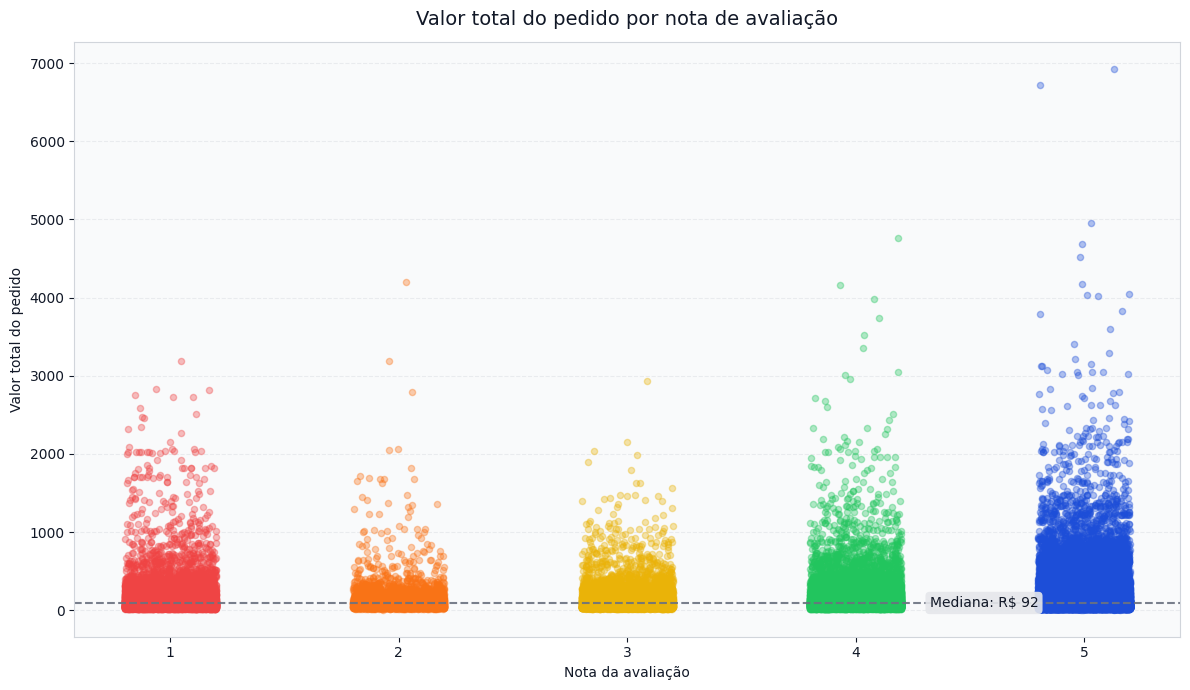

In [18]:
# ============================================================
# GRÁFICO: VALOR TOTAL POR NOTA DE AVALIAÇÃO (REFINADO)
# ============================================================

df_plot = df_avaliacoes.select('nota', 'valor_total').toPandas()

# ------------------------------------------------------------
# Cores por nota (seguindo gradiente lógico)
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",  # vermelho (ruim)
    2: "#F97316",  # laranja
    3: "#EAB308",  # amarelo
    4: "#22C55E",  # verde
    5: "#1D4ED8"   # azul (melhor)
}

# padrão visual
cor_figura = "#FFFFFF"
cor_fundo = "#F9FAFB"
cor_texto = "#111827"
cor_grid = "#D1D5DB"

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot por nota (cores diferentes)
# ------------------------------------------------------------
for nota, df_nota in df_plot.groupby("nota"):
    x_jitter = df_nota["nota"] + np.random.uniform(-0.2, 0.2, size=len(df_nota))

    ax.scatter(
        x_jitter,
        df_nota["valor_total"],
        color=cores_notas.get(nota, "#9CA3AF"),
        alpha=0.35,
        s=20
    )

# ------------------------------------------------------------
# Mediana
# ------------------------------------------------------------
mediana_valor = df_plot["valor_total"].median()

ax.axhline(
    mediana_valor,
    linestyle="--",
    color="#6B7280",
    linewidth=1.5,
    alpha=0.9
)

# BOX da mediana
ax.text(
    4.8,  # joga para direita (evita sobreposição)
    mediana_valor,
    f"Mediana: R$ {mediana_valor:.0f}",
    va="center",
    ha="right",
    fontsize=10,
    color="#111827",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#E5E7EB",
        edgecolor="none",
        alpha=0.9
    )
)

# ------------------------------------------------------------
# Títulos
# ------------------------------------------------------------
ax.set_title(
    "Valor total do pedido por nota de avaliação",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Valor total do pedido", color=cor_texto)

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis='y', linestyle='--', alpha=0.4, color=cor_grid)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)


plt.tight_layout()
plt.show()

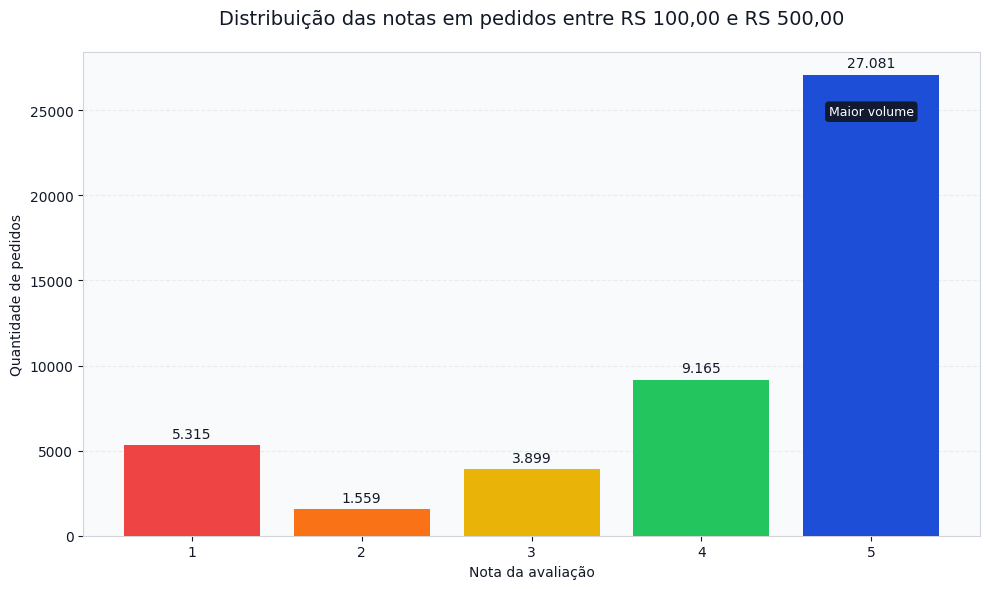

In [19]:
# ============================================================
# GRÁFICO: CONTAGEM DE NOTAS PARA PEDIDOS ENTRE R$ 100 E R$ 500
# ============================================================

# ------------------------------------------------------------
# Filtrar pedidos dentro da faixa de preço analisada
# ------------------------------------------------------------
df_faixa_preco = df_avaliacoes.filter(
    (F.col("valor_total") >= 100) & 
    (F.col("valor_total") <= 500)
)

# ------------------------------------------------------------
# Contar quantidade de pedidos por nota
# ------------------------------------------------------------
df_contagem_notas_faixa = (
    df_faixa_preco
    .groupBy("nota")
    .count()
    .orderBy("nota")
    .toPandas()
)

# ------------------------------------------------------------
# Cores por nota
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",
    2: "#F97316",
    3: "#EAB308",
    4: "#22C55E",
    5: "#1D4ED8"
}

cores = [
    cores_notas.get(int(nota), "#9CA3AF")
    for nota in df_contagem_notas_faixa["nota"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_contagem_notas_faixa["nota"].astype(str),
    df_contagem_notas_faixa["count"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição das notas em pedidos entre RS 100,00 e RS 500,00",
    fontsize=14,
    color=cor_texto,
    pad=20  # <-- aumenta espaço
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Quantidade de pedidos", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + (df_contagem_notas_faixa["count"].max() * 0.01),
        f"{int(altura):,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        color=cor_texto
    )

# ------------------------------------------------------------
# Destaque da nota com maior volume
# ------------------------------------------------------------
nota_mais_frequente = df_contagem_notas_faixa.loc[
    df_contagem_notas_faixa["count"].idxmax(),
    "nota"
]

for bar, nota in zip(bars, df_contagem_notas_faixa["nota"]):
    if nota == nota_mais_frequente:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.92,
            "Maior volume",
            ha="center",
            va="center",
            fontsize=9,
            color="#FFFFFF",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#111827",   # fundo escuro
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

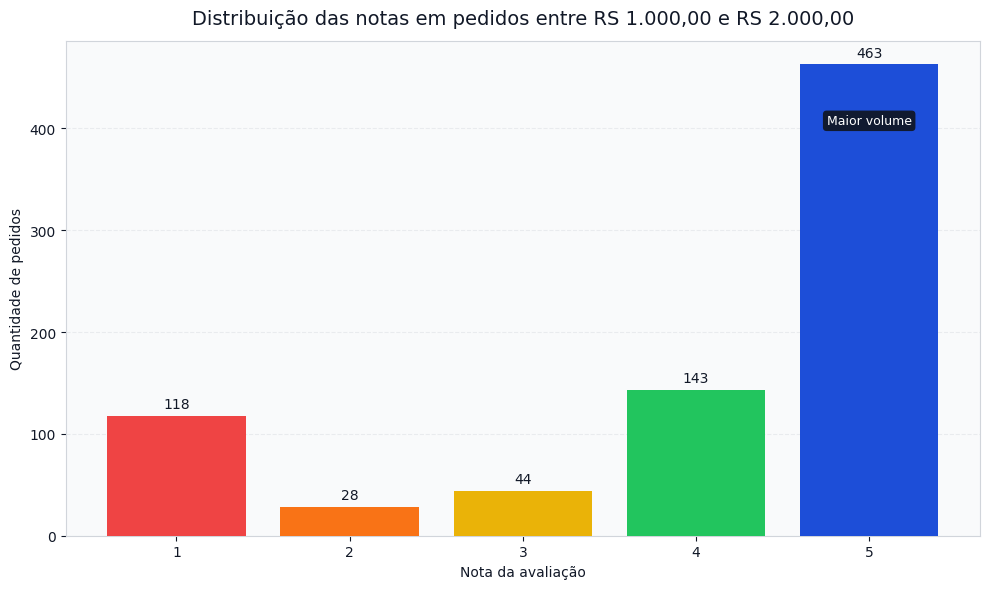

In [20]:
# ============================================================
# GRÁFICO: CONTAGEM DE NOTAS PARA PEDIDOS ENTRE R$ 1.000 E R$ 2.000
# ============================================================

# ------------------------------------------------------------
# Filtrar pedidos dentro da faixa de preço analisada
# ------------------------------------------------------------
df_faixa_preco = df_avaliacoes.filter(
    (F.col("valor_total") >= 1000) &
    (F.col("valor_total") <= 2000)
)

# ------------------------------------------------------------
# Contar quantidade de pedidos por nota
# ------------------------------------------------------------
df_contagem_notas_faixa = (
    df_faixa_preco
    .groupBy("nota")
    .count()
    .orderBy("nota")
    .toPandas()
)

# ------------------------------------------------------------
# Cores por nota
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",
    2: "#F97316",
    3: "#EAB308",
    4: "#22C55E",
    5: "#1D4ED8"
}

cores = [
    cores_notas.get(int(nota), "#9CA3AF")
    for nota in df_contagem_notas_faixa["nota"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_contagem_notas_faixa["nota"].astype(str),
    df_contagem_notas_faixa["count"],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição das notas em pedidos entre RS 1.000,00 e RS 2.000,00",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Quantidade de pedidos", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    altura = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + (df_contagem_notas_faixa["count"].max() * 0.01),
        f"{int(altura):,}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        color=cor_texto
    )

# ------------------------------------------------------------
# Destaque da nota com maior volume
# ------------------------------------------------------------
nota_mais_frequente = df_contagem_notas_faixa.loc[
    df_contagem_notas_faixa["count"].idxmax(),
    "nota"
]

for bar, nota in zip(bars, df_contagem_notas_faixa["nota"]):
    if nota == nota_mais_frequente:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.88,
            "Maior volume",
            ha="center",
            va="center",
            fontsize=9,
            color="#FFFFFF",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#111827",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

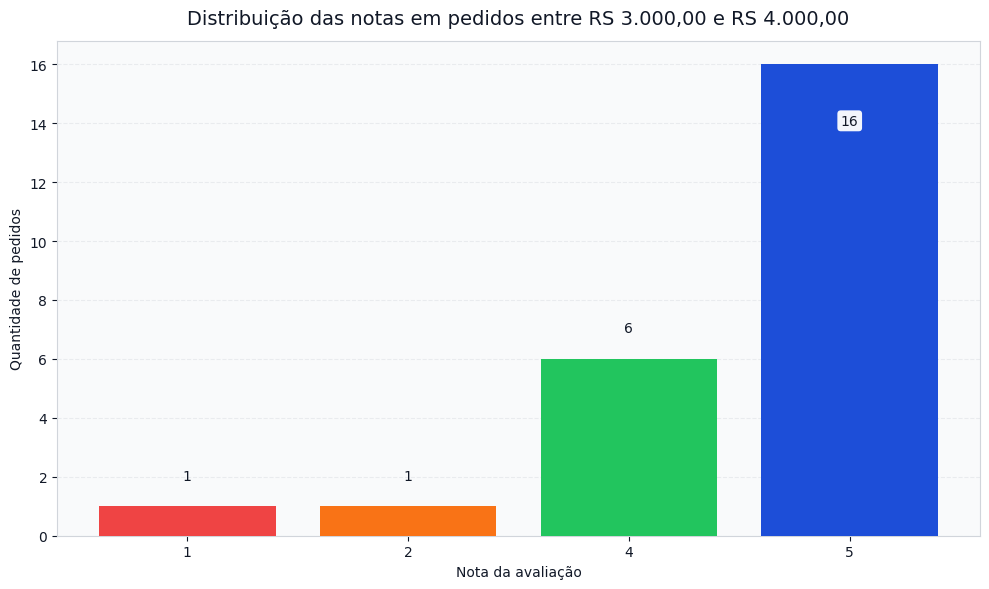

In [21]:
# ============================================================
# GRÁFICO: CONTAGEM DE NOTAS PARA PEDIDOS ENTRE R$ 3.000 E R$ 4.000
# ============================================================

# ------------------------------------------------------------
# Filtrar pedidos dentro da faixa de preço analisada
# ------------------------------------------------------------
df_faixa_preco = df_avaliacoes.filter(
    (F.col("valor_total") >= 3000) &
    (F.col("valor_total") <= 4000)
)

# ------------------------------------------------------------
# Contar quantidade de pedidos por nota
# ------------------------------------------------------------
df_contagem_notas_faixa = (
    df_faixa_preco
    .groupBy("nota")
    .count()
    .orderBy("nota")
    .toPandas()
)

# ------------------------------------------------------------
# Cores por nota (padrão do projeto)
# ------------------------------------------------------------
cores_notas = {
    1: "#EF4444",
    2: "#F97316",
    3: "#EAB308",
    4: "#22C55E",
    5: "#1D4ED8"
}

cores = [
    cores_notas.get(int(nota), "#9CA3AF")
    for nota in df_contagem_notas_faixa["nota"]
]

# ------------------------------------------------------------
# Criar figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_contagem_notas_faixa["nota"].astype(str),
    df_contagem_notas_faixa["count"],
    color=cores,
    edgecolor="none",
    zorder=3 
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title(
    "Distribuição das notas em pedidos entre RS 3.000,00 e RS 4.000,00",
    fontsize=14,
    color=cor_texto,
    pad=12
)

ax.set_xlabel("Nota da avaliação", color=cor_texto)
ax.set_ylabel("Quantidade de pedidos", color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
# Identificar a barra com maior volume
maior_altura = df_contagem_notas_faixa["count"].max()

for bar in bars:
    altura = bar.get_height()

    # MAIOR → dentro com destaque
    if altura == maior_altura:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            altura * 0.88,
            f"{int(altura)}",
            ha="center",
            va="center",
            fontsize=10,
            color="#111827",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="#FFFFFF",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

    # OUTROS → fora da barra
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            altura + (df_contagem_notas_faixa["count"].max() * 0.05),
            f"{int(altura)}",
            ha="center",
            va="bottom",
            fontsize=10,
            color=cor_texto,
            zorder=4
        )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis="y", linestyle="--", alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)

ax.tick_params(colors=cor_texto)

for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

## (2) Quais regiões possuem as melhores notas?

In [22]:
regioes = {
    'AC': 'Norte', 'AM': 'Norte', 'AP': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'MT': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

In [23]:
df_avaliacoes_regiao = df_avaliacoes

In [24]:

coluna_regiao = None

for estado, regiao in regioes.items():
    if coluna_regiao is None:
        coluna_regiao = F.when(F.col("estado_cliente") == estado, regiao)
    else:
        coluna_regiao = coluna_regiao.when(F.col("estado_cliente") == estado, regiao)

if coluna_regiao is not None:
    coluna_regiao = coluna_regiao.otherwise('Outros')
else:
    coluna_regiao = F.lit('Outros')

df_avaliacoes_regiao = df_avaliacoes_regiao.withColumn('regiao', coluna_regiao)

ver_df(df_avaliacoes_regiao.select('estado_cliente', 'regiao', 'nota'))

+--------------+------------+----+
|estado_cliente|regiao      |nota|
+--------------+------------+----+
|MG            |Sudeste     |5   |
|PR            |Sul         |5   |
|SP            |Sudeste     |5   |
|AC            |Norte       |5   |
|SP            |Sudeste     |1   |
|MG            |Sudeste     |5   |
|PA            |Norte       |3   |
|SP            |Sudeste     |5   |
|RN            |Nordeste    |5   |
|BA            |Nordeste    |5   |
|RJ            |Sudeste     |5   |
|PR            |Sul         |5   |
|SP            |Sudeste     |5   |
|SP            |Sudeste     |3   |
|GO            |Centro-Oeste|5   |
|SP            |Sudeste     |5   |
|SP            |Sudeste     |5   |
|SP            |Sudeste     |5   |
|SP            |Sudeste     |4   |
|SP            |Sudeste     |5   |
+--------------+------------+----+
only showing top 20 rows



In [25]:
df_media_notas_regiao = df_avaliacoes_regiao.groupBy('regiao').agg(F.round(F.avg('nota'), 2).alias('media_nota')).orderBy('regiao').toPandas()

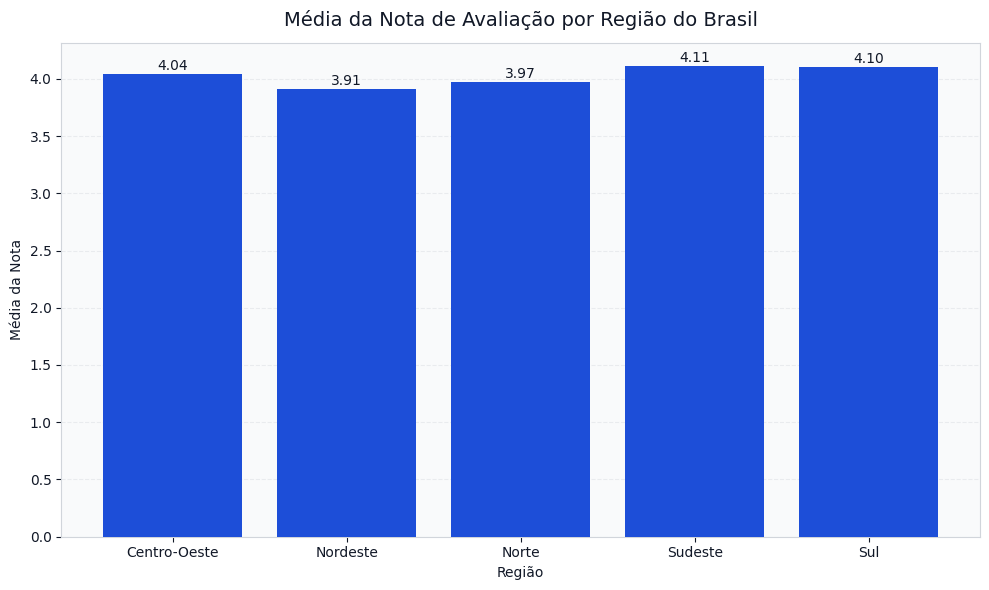

In [26]:
# ============================================================
# GRÁFICO: MÉDIA DA NOTA DE AVALIAÇÃO POR REGIÃO
# ============================================================

# ------------------------------------------------------------
# Padrão visual
# ------------------------------------------------------------
cor_figura = "#FFFFFF"
cor_fundo  = "#F9FAFB"
cor_texto  = "#111827"
cor_grid   = "#D1D5DB"

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_media_notas_regiao['regiao'],
    df_media_notas_regiao['media_nota'],
    color="#1D4ED8",
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title('Média da Nota de Avaliação por Região do Brasil', fontsize=14, color=cor_texto, pad=12)
ax.set_xlabel('Região', color=cor_texto)
ax.set_ylabel('Média da Nota', color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras
# ------------------------------------------------------------
for bar in bars:
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.01,
        f"{altura:.2f}",
        ha="center", va="bottom", fontsize=10, color=cor_texto
    )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.grid(axis='y', linestyle='--', alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors=cor_texto)
for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()

In [27]:
df_contagem_notas_regiao = df_avaliacoes_regiao.groupBy('regiao', 'nota').count().orderBy('regiao', 'nota').toPandas()


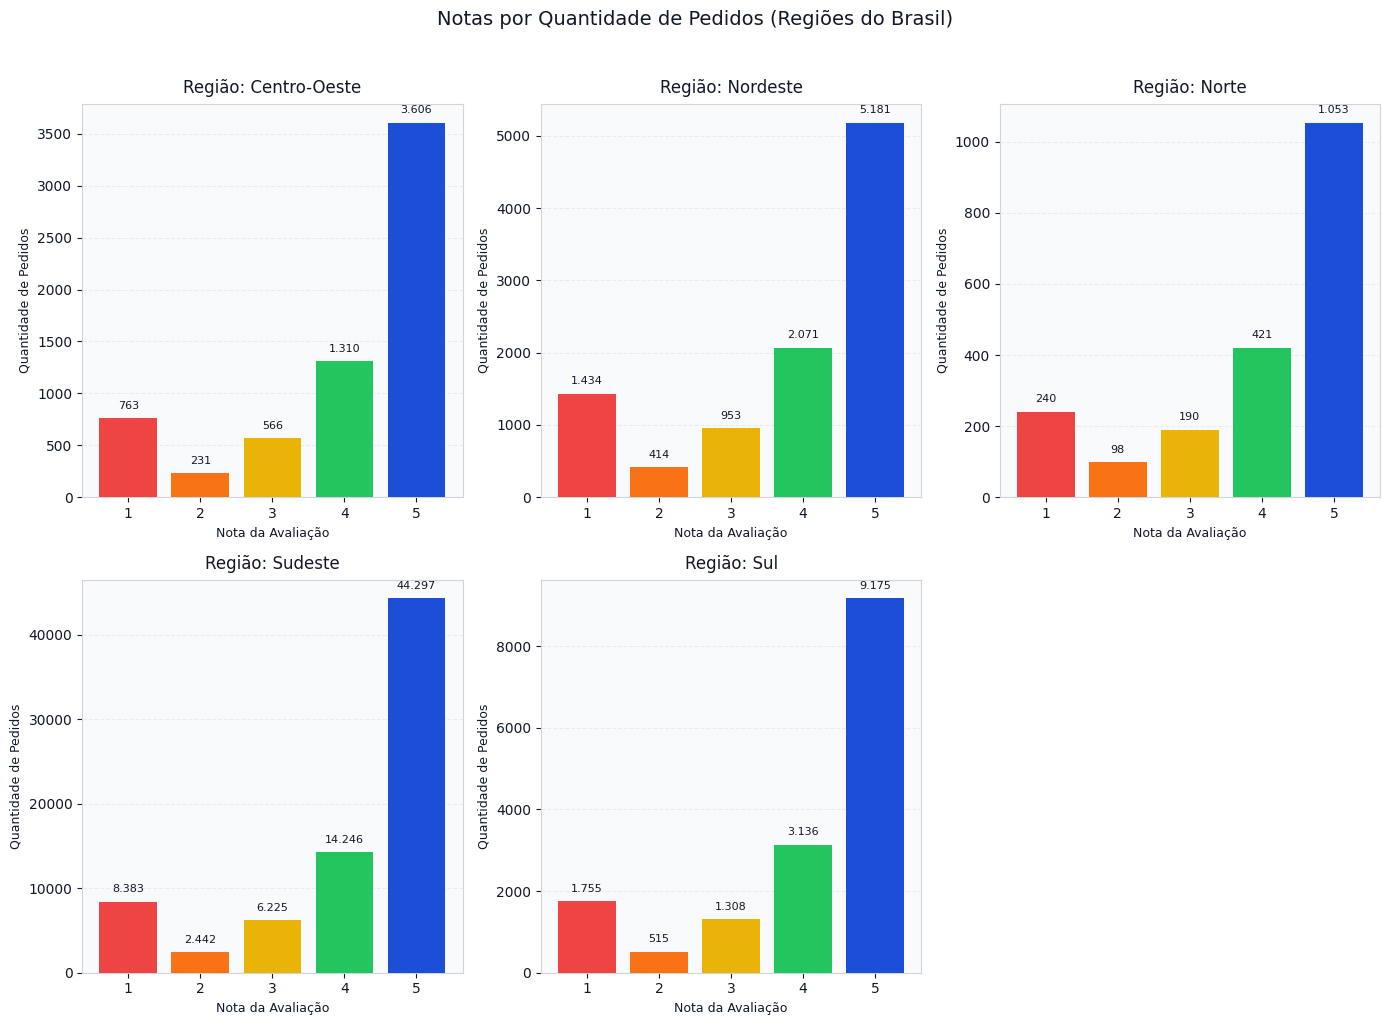

In [28]:
# ============================================================
# GRÁFICO: NOTAS POR QUANTIDADE DE PEDIDOS (REGIÕES DO BRASIL)
# ============================================================

# ------------------------------------------------------------
# Padrão visual
# ------------------------------------------------------------
cores_notas = {1: "#EF4444", 2: "#F97316", 3: "#EAB308", 4: "#22C55E", 5: "#1D4ED8"}
cor_figura = "#FFFFFF"
cor_fundo  = "#F9FAFB"
cor_texto  = "#111827"
cor_grid   = "#D1D5DB"

regioes_lista = sorted(df_contagem_notas_regiao['regiao'].unique())
n_cols = 3
n_rows = -(-len(regioes_lista) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
fig.patch.set_facecolor(cor_figura)
axes_flat = axes.flatten()

# ------------------------------------------------------------
# Subplots por região
# ------------------------------------------------------------
for i, regiao in enumerate(regioes_lista):
    ax = axes_flat[i]
    ax.set_facecolor(cor_fundo)

    df_reg = df_contagem_notas_regiao[df_contagem_notas_regiao['regiao'] == regiao].sort_values('nota')
    cores = [cores_notas.get(int(n), "#9CA3AF") for n in df_reg['nota']]

    bars = ax.bar(df_reg['nota'].astype(str), df_reg['count'], color=cores, edgecolor="none", zorder=3)

    # Título e eixos
    ax.set_title(f"Região: {regiao}", fontsize=12, color=cor_texto, pad=8)
    ax.set_xlabel("Nota da Avaliação", color=cor_texto, fontsize=9)
    ax.set_ylabel("Quantidade de Pedidos", color=cor_texto, fontsize=9)

    # Labels nas barras
    for bar in bars:
        altura = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            altura + df_reg['count'].max() * 0.02,
            f"{int(altura):,}".replace(",", "."),
            ha="center", va="bottom", fontsize=8, color=cor_texto
        )

    # Grid e estilo
    ax.grid(axis='y', linestyle='--', alpha=0.4, color=cor_grid, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(colors=cor_texto)
    for spine in ax.spines.values():
        spine.set_color(cor_grid)

# Ocultar subplots vazios
for j in range(len(regioes_lista), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Notas por Quantidade de Pedidos (Regiões do Brasil)', fontsize=14, color=cor_texto, y=1.02)
plt.tight_layout()
plt.show()

## (3) Qual a diferença Percentual do Total Gasto com base na Avaliação?

In [29]:
df_preco_por_nota = df_avaliacoes.groupBy('nota').agg(F.avg('valor_total').alias('valor_total_medio')).orderBy('nota').toPandas()

### Comparativo do Aumento Percentual do Preço entre Notas Consecutivas

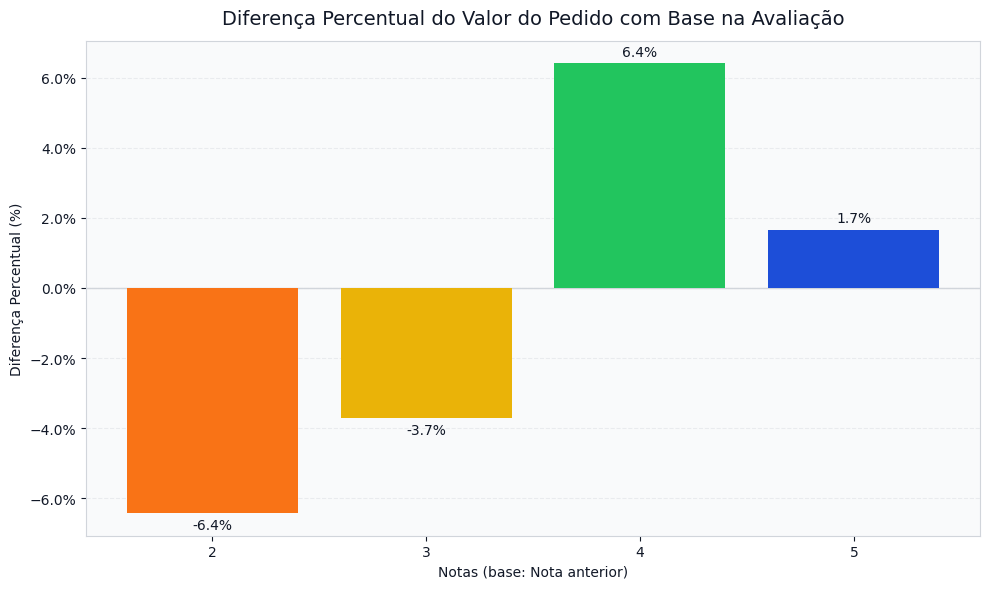

In [30]:
# ------------------------------------------------------------
# Cálculo da diferença percentual consecutiva entre notas
# ------------------------------------------------------------
df_preco_por_nota['valor_total_medio_anterior'] = df_preco_por_nota['valor_total_medio'].shift(1)

df_preco_por_nota['aumento_percentual_consecutivo'] = (
    (df_preco_por_nota['valor_total_medio'] - df_preco_por_nota['valor_total_medio_anterior']) /
    df_preco_por_nota['valor_total_medio_anterior']
) * 100

df_comparativo_consecutivo = df_preco_por_nota.dropna(subset=['aumento_percentual_consecutivo'])

# ============================================================
# GRÁFICO: DIFERENÇA PERCENTUAL DO VALOR POR AVALIAÇÃO
# ============================================================

# ------------------------------------------------------------
# Padrão visual
# ------------------------------------------------------------
cores_notas = {1: "#EF4444", 2: "#F97316", 3: "#EAB308", 4: "#22C55E", 5: "#1D4ED8"}
cor_figura = "#FFFFFF"
cor_fundo  = "#F9FAFB"
cor_texto  = "#111827"
cor_grid   = "#D1D5DB"

cores = [cores_notas.get(int(n), "#9CA3AF") for n in df_comparativo_consecutivo['nota']]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(cor_figura)
ax.set_facecolor(cor_fundo)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
bars = ax.bar(
    df_comparativo_consecutivo['nota'].astype(str),
    df_comparativo_consecutivo['aumento_percentual_consecutivo'],
    color=cores,
    edgecolor="none",
    zorder=3
)

# ------------------------------------------------------------
# Título e eixos
# ------------------------------------------------------------
ax.set_title('Diferença Percentual do Valor do Pedido com Base na Avaliação', fontsize=14, color=cor_texto, pad=12)
ax.set_xlabel('Notas (base: Nota anterior)', color=cor_texto)
ax.set_ylabel('Diferença Percentual (%)', color=cor_texto)

# ------------------------------------------------------------
# Labels nas barras (posição adaptada para valores negativos)
# ------------------------------------------------------------
for bar in bars:
    altura = bar.get_height()
    offset = df_comparativo_consecutivo['aumento_percentual_consecutivo'].abs().max() * 0.02
    va = "bottom" if altura >= 0 else "top"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + (offset if altura >= 0 else -offset),
        f"{altura:.1f}%",
        ha="center", va=va, fontsize=10, color=cor_texto
    )

# ------------------------------------------------------------
# Grid e estilo
# ------------------------------------------------------------
ax.axhline(0, color=cor_grid, linewidth=1, zorder=2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', linestyle='--', alpha=0.4, color=cor_grid, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(colors=cor_texto)
for spine in ax.spines.values():
    spine.set_color(cor_grid)

plt.tight_layout()
plt.show()